<img src="https://github.com/GJay99/Trabajos_APS/blob/master/TS0/logo_UNSAM.jpg?raw=1" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Gonzalo Jay

# Introducción
Durante la resolución de esta tarea semanal fuimos aprendiendo sobre la utilización de dos herramientas fundamentales en el análisis y procesamiento de señales, el ventaneo y los estimadores.

Empezando por el ventaneo, esta es una herramienta que venimos utilizando de manera implícita. Al momento de procesar una señal la misma no puede ser de duración infinita, siempre nos quedamos con una cantidad finita de puntos de la misma. Para lograr esto es que aplicamos el ventaneo. Usualmente, lo que hacemos al quedarnos con N puntos de la misma es usar una ventana rectangular de amplitud unitaria y ancho N. Pero esta no es la única forma de ventaneo que existe.

La elección de esta ventana no es trivial, ya que la misma afectará a la respuesta en frecuencia de la señal debido a la convolución del espectro de la señal original con el espectro de la ventana, algo que vimos levemente en la TS3. Las ventanas que se utilizan, al aplicarle la FFT, suelen dar como resultado variantes de la Sinc. Lo que principalmente variará de la misma es el ancho del lóbulo principal y la diferencia de amplitud entre este mismo y el primer secundario. Estas características son las que deberemos analizar a la hora de elegir una ventana u otra en nuestra aplicación.

En este trabajo hemos utilizado las ventanas rectangular, Flat-Top, Blackman-Harris y hemos elegido la Hamming.

Por el lado de los estimadores, estos son una herramienta muy común en los cálculos de probabilidad y estadística. A lo largo de los trabajos anteriores hemos asumido conocer ciertos detalles sobre las distribuciones de probabilidad para calcular la esperanza o la varianza de ciertas señales. Lo cierto es que, en la vida real, es casi imposible contar con la función densidad de probabilidad de estas distribuciones.

Es por esto que debemos utilizar estimadores para, justamente, estimar el verdadero valor del parámetro de interés con un numero finito de observaciones. 
En este trabajo hemos aplicado los estimadores:
\begin{equation}
\widehat{a}_1^i = |X_w^i(\Omega_0)|= |\mathcal{F}\{x_{[n]}.w_{i[n]}\}|
\end{equation}
\begin{equation}
\widehat{\Omega}_1^i = arg_fmax\{|X_w^i(\Omega)|\}
\end{equation}
Es decir que estimaremos la amplitud de la señal mediante el valor de la transformada de Fourier en $\Omega_0$ y la frecuencia de la misma con la frecuencia a la cuál la transformada tiene su máximo.

Estos estimadores contarán con un sesgo y una varianza. El sesgo es la diferencia entre el valor esperado del estimador y el valor verdadero que intenta estimar.
\begin{equation}
s_a = E\{\widehat{a}_1\} - a_0
\end{equation}
Si el sesgo es cero se dice que es un estimador insesgado. Si al hacer tender N a infinito el sesgo tiende a 0 se le dice asintóticamente insesgado.

Por otro lado la varianza nos habla sobre que tanto varia el valor del estimador. Para que un estimador sea consistente esta varianza debe tender a cero al aumentar N.
\begin{equation}
v_a = var_\{\widehat{a}_1\} = E\{(\widehat{a}_1-E\{\widehat{a}_1\})^2\}
\end{equation}

# Resolución
Como siempre, debemos comenzar incluyendo las librerías necesarias. En este caso esto incluye scipy.signal.windows, la cuál es necesaria para generar las ventanas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as win 

También las constantes necesarias y la función para calcular la FFT, con la pequeña modificación de incluir el axis sobre el cuál hacerla ahora que nuestra función será una matriz y no un vector. Explicaré esto más adelante. También agregamos una semilla para evitar que cada vez que corramos el código ciertos valores cambien, provocando discordancias con el texto.

In [2]:
N=1000
fs=1000

np.random.seed(99)

In [3]:
def mi_fft(x, fs=fs):
    x_fft = np.fft.fft(x, axis=1)
    
    x_fft = x_fft[:,:N//2]
    
    freq = np.fft.fftfreq(N, 1/fs)[:N//2]
    x_fft_abs = np.abs(x_fft)
    
    return freq, x_fft_abs

En este trabajo se nos pidió que utilicemos una frecuencia $\Omega_1$ la cual constaba de una $\Omega_0=\frac{\pi}{2}$ sumada a una componente aleatoria de la forma:
\begin{equation}
f_r * \frac{2.\pi}{N}
\end{equation}
\begin{equation}
f_r \sim \mathcal{U}(-2, 2)
\end{equation}
Es decir, que la frecuencia de la señal podrá estar, cuanto mucho, a dos bins de distancia de la frecuencia central, la cual estará en 250 Hz. Además de esta manera se realizarán doscientas realizaciones, es decir, tomaremos 200 valores de $f_r$.

In [4]:
omega_cero = np.pi/2

f_r = np.random.uniform(-2,2,size=200)
omega_uno = omega_cero + f_r * 2 * np.pi/N

Luego en base a estos doscientos valores de $\Omega_1$ se generará una matriz de senoidales, donde las filas representarán distintas realizaciones y las columnas las distintas muestras de una misma frecuencia. Para esto fue necesario utilizar la función np.outer, la cuál realiza la operación matemática conocida como producto exterior o producto tensorial. Es decir, multiplica cada elemento del primer vector por todos los elementos del segundo vector, cada resultado en una posición distinta.

In [5]:
nn = np.arange(0,N,1)
s = np.sqrt(2)*np.sin(np.outer(omega_uno,nn))
t = nn/fs
Ps = np.var(s)

## Análisis ventaneo y estimadores con SNR = 3 dB
Para alcanzar el SNR deseado reciclaremos una función utilizada en una TS anterior, la cuál al darle un valor de SNR devuelve el valor necesario del desvío estándar para obtener la relación señal ruido, con ruido gaussiano, deseada. Luego agregamos este ruido a nuestro vector de senoidales.

In [6]:
SNR = 3

sigma = np.sqrt(Ps/np.power(10,SNR/10)) 
n_a = np.random.normal(scale=sigma,size=s.shape)

In [7]:
x = s + n_a

A partir de este paso, es cuando empezaremos a aplicar las ventanas. Como primer ventana nos encontramos con la rectangular. Para esto no es necesario agregar ninguna función, ya que al realizar la FFT de una señal discreta ya se considera que esta ventana se encuentra implícitamente presente. Procedemos a realizar esta transformada sobre las señales y graficarlas todas en el mismo plot.

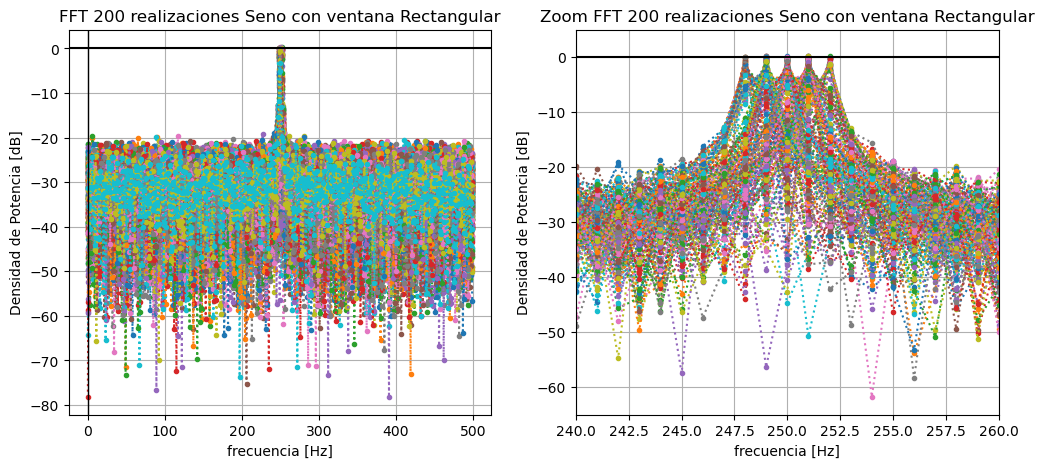

In [8]:
freq, x_fft_abs = mi_fft(x)
x_fft_abs_norm = 2*x_fft_abs/N
x_fft_abs_traspuesta = np.transpose(x_fft_abs_norm)

ref=np.max(np.sqrt(2))
x_fft_abs_dB=20*np.log10(x_fft_abs_traspuesta/ref)

plt.figure(2, figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(freq,x_fft_abs_dB,":.")
plt.title("FFT 200 realizaciones Seno con ventana Rectangular")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.subplot(1, 2, 2)
plt.plot(freq,x_fft_abs_dB,":.")
plt.title("Zoom FFT 200 realizaciones Seno con ventana Rectangular")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.xlim(240,260)
plt.ylim(-65,5)
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Como podemos ver, en este gráfico se aprecia lo que esperábamos. En 0 dB, o valores muy cercanos, existirán picos en $\{248Hz,249Hz,250Hz,251Hz,252Hz\}$. Estos $\delta$ difícilmente sean perfectos, ya que al agregar un valor dependiente de una distribución aleatoria a la frecuencia, las probabilidades de que la frecuencia caiga perfectamente sobre un bin son considerablemente bajas.

Continuamos con la ventana conocida como Flat-Top. Al ser la primera vez que la utilizamos, nos pareció interesante plotearla en conjunto con la señal modificada para observar como se comporta.

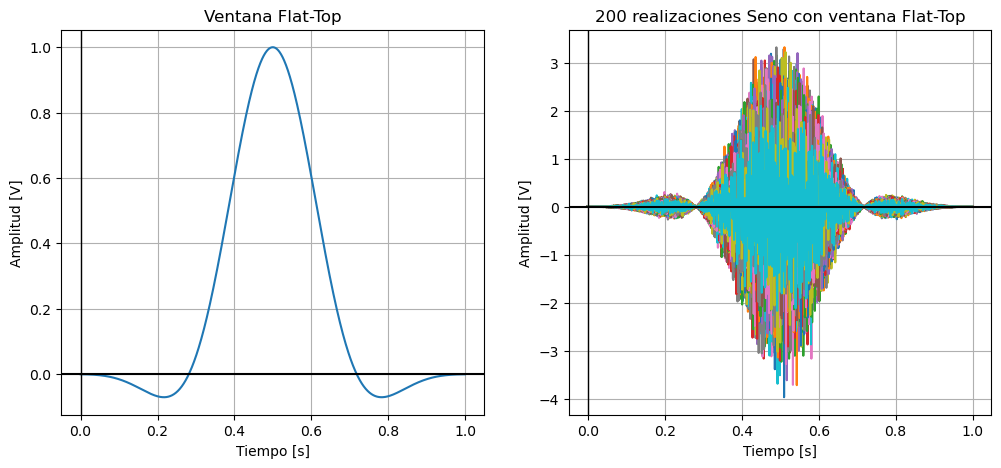

In [9]:
flat=win.flattop(N)
x_flat=flat*x

plt.figure(2, figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t,flat)
plt.title("Ventana Flat-Top")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.subplot(1, 2, 2)
plt.plot(t,np.transpose(x_flat))
plt.title("200 realizaciones Seno con ventana Flat-Top")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)


Y continuamos calculando su FFT.

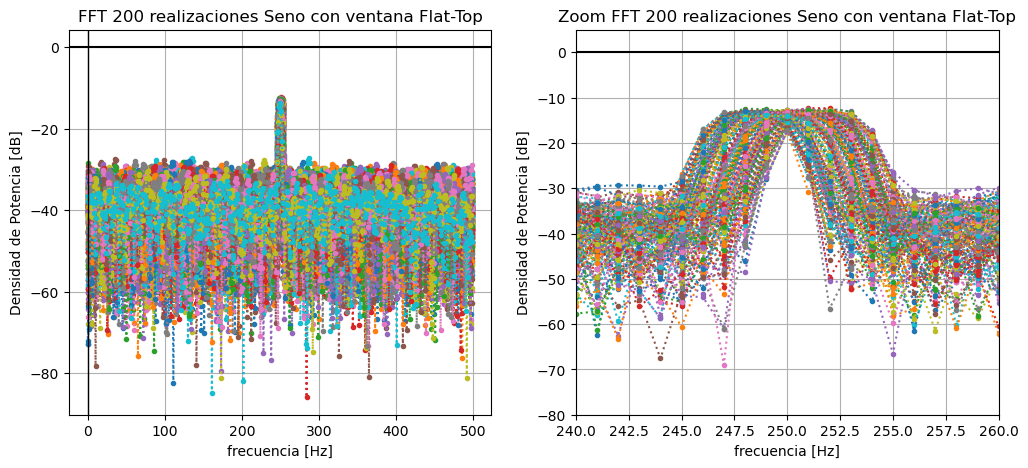

In [10]:
freq, x_flat_fft_abs = mi_fft(x_flat)
x_flat_fft_abs_norm = 2*x_flat_fft_abs/N
x_flat_fft_abs_traspuesta = np.transpose(x_flat_fft_abs_norm)

x_flat_fft_abs_dB=20*np.log10(x_flat_fft_abs_traspuesta/ref)

plt.figure(3, figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(freq,x_flat_fft_abs_dB,":.")
plt.title("FFT 200 realizaciones Seno con ventana Flat-Top")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.subplot(1, 2, 2)
plt.plot(freq,x_flat_fft_abs_dB,":.")
plt.xlim(240,260)
plt.ylim(-80,5)
plt.title("Zoom FFT 200 realizaciones Seno con ventana Flat-Top")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Podemos ver como la amplitud de la transformada disminuyó, teniendo ahora como máximo valores claramente inferiores a los -10dB. Esto se debe a que, por la forma de la ventana, si no se realiza ninguna normalización que contrareste, se perderá una parte de la energía de la señal. Sin embargo veremos que esto trae consigo algunas ventajas.

Haremos el mismo proceso con las ventanas de Blackman-Harris y Hamming, sobre las cuáles por ahora no comentaré mucho debido a que el proceso es igual al caso anterior.

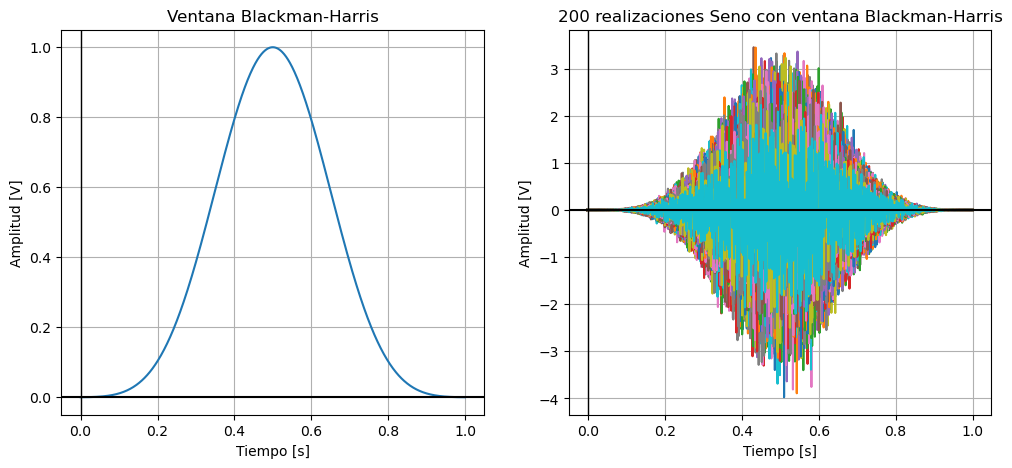

In [11]:
blackh=win.blackmanharris(N)
x_blackh=x*blackh

plt.figure(4, figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t,blackh)
plt.title("Ventana Blackman-Harris")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.subplot(1, 2, 2)
plt.plot(t,np.transpose(x_blackh))
plt.title("200 realizaciones Seno con ventana Blackman-Harris")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

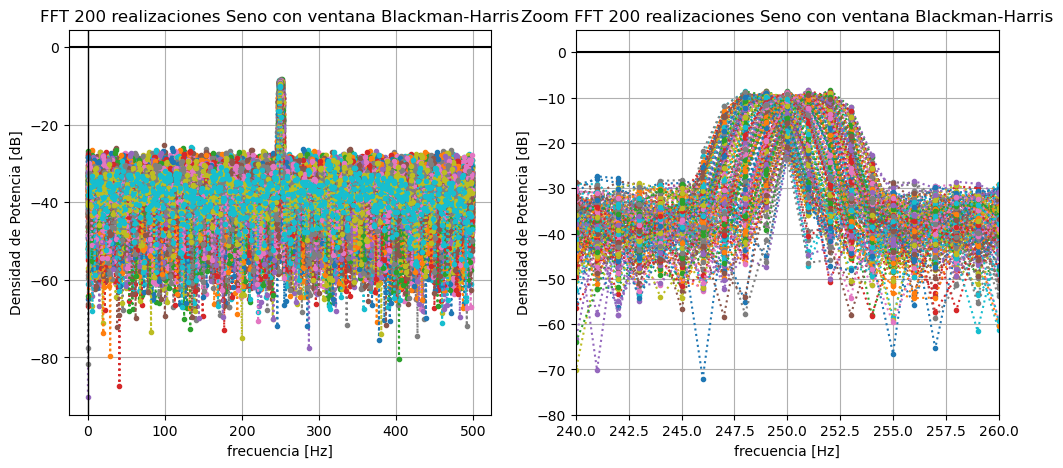

In [12]:
freq, x_bh_fft_abs = mi_fft(x_blackh)
x_bh_fft_abs_norm = 2*x_bh_fft_abs/N
x_bh_fft_abs_traspuesta = np.transpose(x_bh_fft_abs_norm)

x_bh_fft_abs_dB=20*np.log10(x_bh_fft_abs_traspuesta/ref)

plt.figure(5, figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(freq,x_bh_fft_abs_dB,":.")
plt.title("FFT 200 realizaciones Seno con ventana Blackman-Harris")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.subplot(1, 2, 2)
plt.plot(freq,x_bh_fft_abs_dB,":.")
plt.xlim(240,260)
plt.ylim(-80,5)
plt.title("Zoom FFT 200 realizaciones Seno con ventana Blackman-Harris")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Decidimos emplear la de Hamming como nuestra ventana a elección porque tras una breve búsqueda en internet resulto ser de las más utilizadas en el campo de la biomédica, excluyendo a las ya incluidas de manera obligatoria en el trabajo práctico.

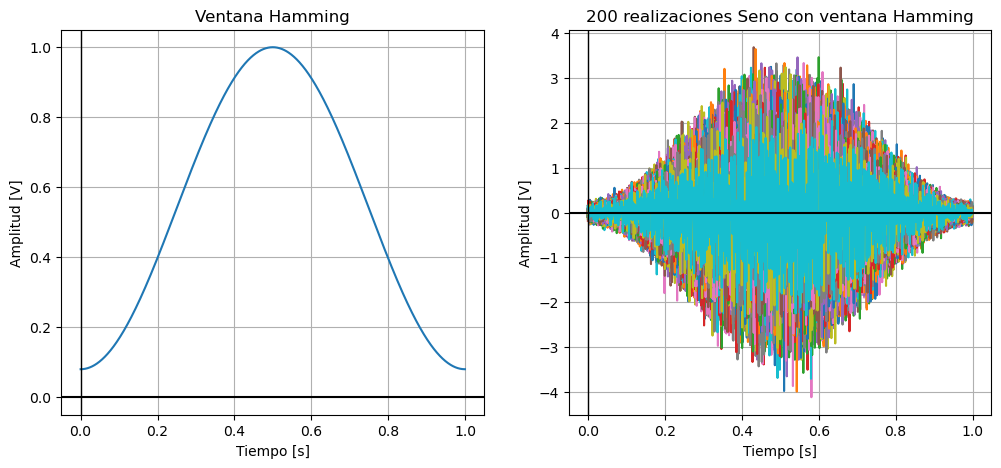

In [13]:
hamm = win.hamming(N)
x_hamm = x * hamm

plt.figure(6, figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t,hamm)
plt.title("Ventana Hamming")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.subplot(1, 2, 2)
plt.plot(t,np.transpose(x_hamm))
plt.title("200 realizaciones Seno con ventana Hamming")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

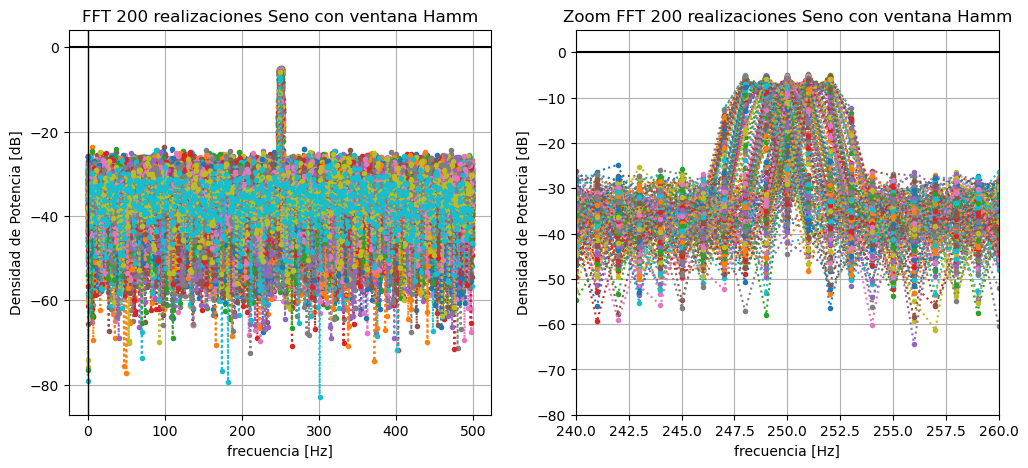

In [14]:
freq, x_hamm_fft_abs = mi_fft(x_hamm)
x_hamm_fft_abs_norm = 2*x_hamm_fft_abs/N
x_hamm_fft_abs_traspuesta = np.transpose(x_hamm_fft_abs_norm)

x_hamm_fft_abs_dB=20*np.log10(x_hamm_fft_abs_traspuesta/ref)

plt.figure(7, figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(freq,x_hamm_fft_abs_dB,":.")
plt.title("FFT 200 realizaciones Seno con ventana Hamm")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.subplot(1, 2, 2)
plt.plot(freq,x_hamm_fft_abs_dB,":.")
plt.xlim(240,260)
plt.ylim(-80,5)
plt.title("Zoom FFT 200 realizaciones Seno con ventana Hamm")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Ahora llegamos al análisis verdaderamente interesante de este trabajo, ya que veremos como afectan las ventanas a nuestros estimadores y cuál es la mejor para cada caso.

Comenzamos calculando el estimador $\widehat{a}_1$ para cada ventana de la siguiente manera:

In [15]:
a_1_rect = x_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]
a_1_flat = x_flat_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]
a_1_bh = x_bh_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]
a_1_hamm = x_hamm_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]

Y, a continuación, realizamos un histograma comparando los valores del estimador en las distintas ventanas

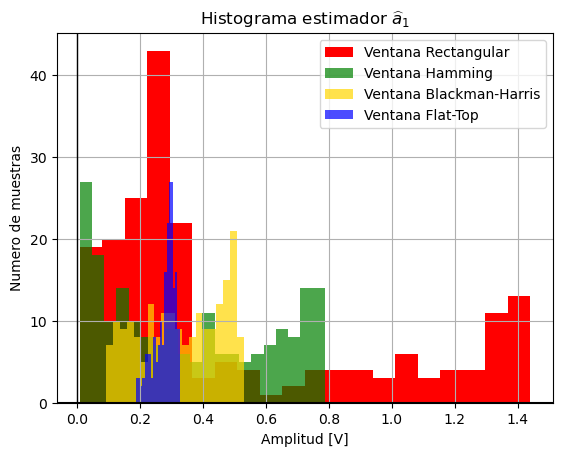

In [16]:
plt.figure(8)
plt.hist(a_1_rect, bins=20, color="red", label="Ventana Rectangular")
plt.hist(a_1_hamm, bins=20, color="green", alpha=0.7, label="Ventana Hamming")
plt.hist(a_1_bh, bins=20, color="gold", alpha=0.7, label="Ventana Blackman-Harris")
plt.hist(a_1_flat, bins=20, color="blue", alpha=0.7, label="Ventana Flat-Top")
plt.title("Histograma estimador $\widehat{a}_1$")
plt.ylabel("Numero de muestras")
plt.xlabel("Amplitud [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.legend()

Lo que podemos apreciar es como la ventana rectangular es la única que llega a un valor cercano a $\sqrt{2}$, el cuál es el valor que idealmente debería alcanzar este estimador. Sin embargo, tiene en su contra que la mayoría de los puntos se encuentra mas cerca del 0 desviando la media de este punto. Sin mencionar que este estimador tiene una varianza muy grande.

Las ventanas de Hamming y Blackman-Harris se alejan mas a simple vista del valor deseado, pero disminuyen la varianza lo cuál hace que estos estimadores sean mejores. Sin embargo, el estimador obtenido mediante la ventana Flat-Top pareciera ser la mejor, porque si bien aparenta ser la de mayor sesgo, su varianza es muy chica. 

Esta consideración de que una varianza baja sea mejor que un sesgo bajo se debe a que el sesgo se puede corregir mediante una simple modificación lineal del estimador, como veremos en la sección bonus. Sin embargo, corregir la varianza es un proceso mas complejo, el cuál incluso puede resultar imposible si no deseamos modificar la ventana.

Procederemos a realizar un cuadro donde compararemos el sesgo y la varianza del estimador para cada ventana de manera numérica. Para esto asumimos la media muestral como un aproximador de la esperanza:
\begin{equation}
E_{\{\widehat{a}_1\}}=\widehat{\mu}_{\widehat{a}_1}=\frac{1}{M}\sum_{i=0}^{M-1} \widehat{a}_1^i
\end{equation}

In [17]:
print("Rectangular:")
print(f"Media est_a1:{np.round(np.mean(a_1_rect),3)} y Varianza:{np.round(np.var(a_1_rect),3)}")
sesgo_a1_rect = np.mean(a_1_rect) - np.sqrt(2)
print(f"Sesgo:{np.round(sesgo_a1_rect,3)}")

print("Flat-Top:")
print(f"Media est_a1:{np.round(np.mean(a_1_flat),3)} y Varianza:{np.round(np.var(a_1_flat),3)}")
sesgo_a1_flat = np.mean(a_1_flat) - np.sqrt(2)
print(f"Sesgo:{np.round(sesgo_a1_flat,3)}")

print("Blackman-Harris:")
print(f"Media est_a1:{np.round(np.mean(a_1_bh),3)} y Varianza:{np.round(np.var(a_1_bh),3)}")
sesgo_a1_bh = np.mean(a_1_bh) - np.sqrt(2)
print(f"Sesgo:{np.round(sesgo_a1_bh,3)}")

print("Hamming:")
print(f"Media est_a1:{np.round(np.mean(a_1_hamm),3)} y Varianza:{np.round(np.var(a_1_hamm),3)}")
sesgo_a1_hamm = np.mean(a_1_hamm) - np.sqrt(2)
print(f"Sesgo:{np.round(sesgo_a1_hamm,3)}")

Rectangular:
Media est_a1:0.495 y Varianza:0.202
Sesgo:-0.919
Flat-Top:
Media est_a1:0.279 y Varianza:0.001
Sesgo:-1.136
Blackman-Harris:
Media est_a1:0.33 y Varianza:0.016
Sesgo:-1.084
Hamming:
Media est_a1:0.35 y Varianza:0.067
Sesgo:-1.064


| Ventana | $s_{\widehat{a}_1}$ | $v_{\widehat{a}_1}$ |
|---|---:|---:|
| Rectangular | -0.919 | 0.202 |
| Flat-Top | -1.136 | 0.001 |
| Blackman-Harris | -1.084 | 0.016 |
| Hamming | -1.064 | 0.067 |

Este cuadro demuestra nuestra suposición inicial. En este caso lo que mas nos importa es destacar como la ventana rectangular es la que tiene un sesgo mas bajo, pero al ser la que cuenta con mayor varianza queda descartada como un buen estimador, ya que será muy poco probable que sea un estimador consistente. En cambio la Flat-Top es la de mayor sesgo como habíamos anticipado, pero tiene una varianza muy chica en comparación al resto. Esto nos hace ver que, para las condiciones de nuestro experimento, la ventana Flat-Top pareciera ser la mejor, aunque si deseamos utilizarlo deberemos modificarlo como ya mencionamos.

En el caso del estimador $\widehat{\Omega}_1$ utilizaremos la función np.argmax, la cuál justamente hace lo que se nos pide que haga el estimador. Esta función recibe una matriz y el eje sobre el cuál debe analizar y buscar el indice el cuál maximiza el valor de la matriz en el axis deseado. Luego convertimos esto en una frecuencia angular para tener un resultado consistente con lo que buscamos.

In [18]:
indice_maximo = np.argmax(x_fft_abs, axis=1)
omega_rect = freq[indice_maximo]*2*np.pi/fs
indice_maximo = np.argmax(x_flat_fft_abs, axis=1)
omega_flat = freq[indice_maximo]*2*np.pi/fs
indice_maximo = np.argmax(x_bh_fft_abs, axis=1)
omega_bh = freq[indice_maximo]*2*np.pi/fs
indice_maximo = np.argmax(x_hamm_fft_abs, axis=1)
omega_hamm = freq[indice_maximo]*2*np.pi/fs

Nuevamente, realizamos el histograma de los 4 estimadores.

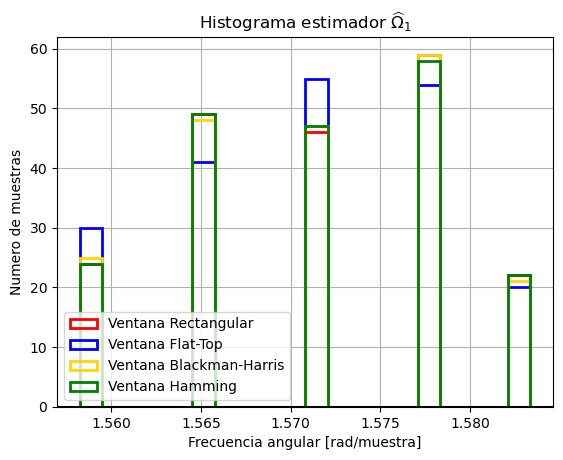

In [19]:
plt.figure(9)
plt.hist(omega_rect, bins=20, color="red", histtype="step", linewidth=2,label="Ventana Rectangular")
plt.hist(omega_flat, bins=20, color="blue", histtype="step", linewidth=2,label="Ventana Flat-Top")
plt.hist(omega_bh, bins=20, color="gold", histtype="step", linewidth=2,label="Ventana Blackman-Harris")
plt.hist(omega_hamm, bins=20, color="green", histtype="step", linewidth=2,label="Ventana Hamming")
plt.title("Histograma estimador $\widehat{\Omega}_1$")
plt.ylabel("Numero de muestras")
plt.xlabel("Frecuencia angular [rad/muestra]")
plt.grid()
plt.axhline(0,color="black")
plt.legend()

Podemos ver como, en principio, se cumple la teoría de que al contar con una frecuencia angular de $\frac{\pi}{2}$ sumado con una uniforme entre -2 y 2, los máximos se deben concentrar principalmente en 5 bins en total, con $\frac{\pi}{2}$ en el medio y los dos bins adyacentes para cada lado. Además podemos apreciar algo interesante, y es que la elección de la ventana pareciera no tener prácticamente repercusiones en el funcionamiento del estimador.

Para ver esto con mayor detenimiento, realizamos el cuadro comparativo.

In [20]:
print("Rectangular:")
print(f"Media est_omega:{np.round(np.mean(omega_rect),3)} y Varianza:{np.var(omega_rect):.1g}")
sesgo_omega_rect = np.mean(omega_rect - omega_uno)
print(f"Sesgo:{sesgo_omega_rect:.1g}")

print("Flat-Top:")
print(f"Media est_omega:{np.round(np.mean(omega_flat),3)} y Varianza:{np.var(omega_flat):.1g}")
sesgo_omega_flat = np.mean(omega_flat - omega_uno)
print(f"Sesgo:{sesgo_omega_flat:.1g}")

print("Blackman-Harris:")
print(f"Media est_omega:{np.round(np.mean(omega_bh),3)} y Varianza:{np.var(omega_bh):.1g}")
sesgo_omega_bh = np.mean(omega_bh - omega_uno)
print(f"Sesgo:{sesgo_omega_bh:.1g}")

print("Hamming:")
print(f"Media est_omega:{np.round(np.mean(omega_hamm),3)} y Varianza:{np.var(omega_hamm):.1g}")
sesgo_omega_hamm = np.mean(omega_hamm - omega_uno)
print(f"Sesgo:{sesgo_omega_hamm:.1g}")

Rectangular:
Media est_omega:1.571 y Varianza:6e-05
Sesgo:9e-05
Flat-Top:
Media est_omega:1.571 y Varianza:6e-05
Sesgo:-0.0003
Blackman-Harris:
Media est_omega:1.571 y Varianza:6e-05
Sesgo:-4e-07
Hamming:
Media est_omega:1.571 y Varianza:6e-05
Sesgo:6e-05


| Ventana | $s_{\widehat{\Omega}_1}$ | $v_{\widehat{\Omega}_1}$ |
|---|---:|---:|
| Rectangular | $9.10^{-5}$ | $6.10^{-5}$ |
| Flat-Top | $-3.10^{-4}$ | $6.10^{-5}$ |
| Blackman-Harris | $-4.10^{-7}$ | $6.10^{-5}$ |
| Hamming | $6.10^{-5}$ | $6.10^{-5}$ |

Efectivamente podemos ver como todos los estimadores tienen un sesgo muy similar, prácticamente nulo, al igual que la varianza. Esto nos hace creer que este estimador es un estimador muy robusto, el cuál es capaz de estimar $\Omega_1$ con precisión, sin importar que ventana utilicemos.

## Análisis ventaneo y estimadores con SNR = 10 dB

Continuamos viendo que sucede si en vez de 3 dB utilizamos como relación señal ruido unos 10 dB. Iniciamos igual que en el caso anterior, calculando el desvío estándar para la señal ruidosa para luego añadirla al seno.

In [21]:
SNR = 10

sigma = np.sqrt(Ps/np.power(10,SNR/10)) 
n_a = np.random.normal(scale=sigma,size=s.shape)

In [22]:
x = s + n_a

Luego calculamos la FFT de esta señal con las distintas ventanas. Con el objetivo de evitar rellenar el informe de gráficos innecesarios, solo graficaré la FFT de la ventana rectangular para observar que consecuencia visual traerá consigo el cambio en el SNR. En principio lo que se podría apreciar es como el piso de ruido disminuye su amplitud, sin embargo esto será complicado de apreciar debido a dos razones: el desparramo espectral debido a frecuencias que no sintonizan con ningún bin y la superposición de 200 señales.

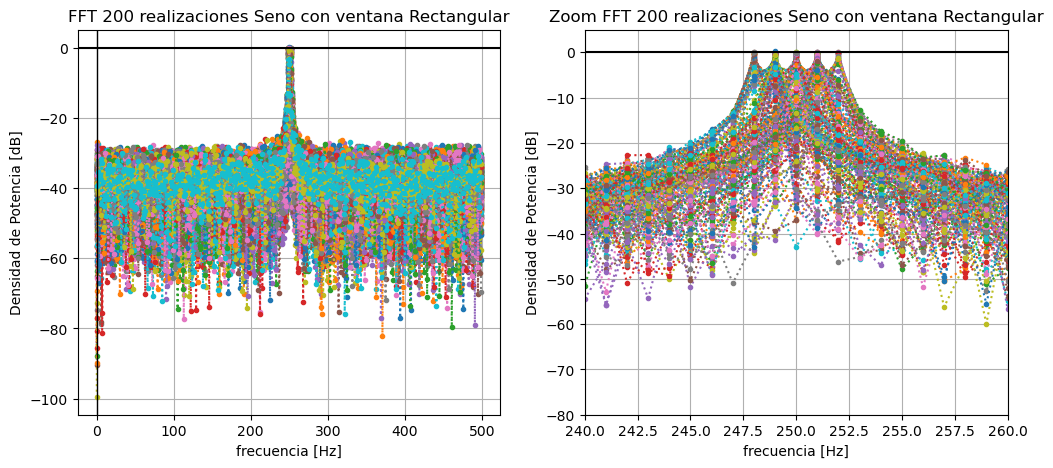

In [23]:
freq, x_fft_abs = mi_fft(x)
x_fft_abs_norm = 2*x_fft_abs/N
x_fft_abs_traspuesta = np.transpose(x_fft_abs_norm)

ref=np.max(np.sqrt(2))
x_fft_abs_dB=20*np.log10(x_fft_abs_traspuesta/ref)

plt.figure(10, figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(freq,x_fft_abs_dB,":.")
plt.title("FFT 200 realizaciones Seno con ventana Rectangular")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

plt.subplot(1, 2, 2)
plt.plot(freq,x_fft_abs_dB,":.")
plt.title("Zoom FFT 200 realizaciones Seno con ventana Rectangular")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.xlim(240,260)
plt.ylim(-80,5)
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Podemos ver como efectivamente el piso de ruido se encuentra mas bajo que en la misma figura del inciso anterior, aunque no logramos distinguir los aproximadamente 7 dB de diferencia pero se nota una disminución del piso. Este cambio será igual para las otras tres ventanas, por lo cuál avanzamos directamente al análisis de los estimadores.

In [24]:
flat=win.flattop(N)
x_flat=flat*x
freq, x_flat_fft_abs = mi_fft(x_flat)
x_flat_fft_abs_norm = 2*x_flat_fft_abs/N

In [25]:
blackh=win.blackmanharris(N)
x_blackh=x*blackh
freq, x_bh_fft_abs = mi_fft(x_blackh)
x_bh_fft_abs_norm = 2*x_bh_fft_abs/N

In [26]:
hamm = win.hamming(N)
x_hamm = x * hamm
freq, x_hamm_fft_abs = mi_fft(x_hamm)
x_hamm_fft_abs_norm = 2*x_hamm_fft_abs/N

Volvemos a realizar el mismo procedimiento de antes para calcular el estimador de amplitud y realizamos su histograma.

In [27]:
a_1_rect = x_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]
a_1_flat = x_flat_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]
a_1_bh = x_bh_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]
a_1_hamm = x_hamm_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]

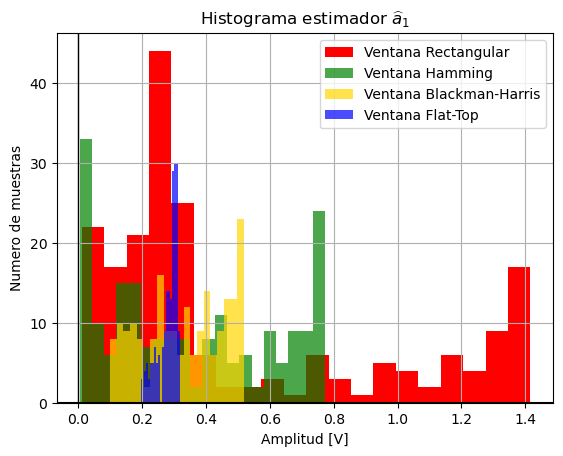

In [28]:
plt.figure(11)
plt.hist(a_1_rect, bins=20, color="red", label="Ventana Rectangular")
plt.hist(a_1_hamm, bins=20, color="green", alpha=0.7, label="Ventana Hamming")
plt.hist(a_1_bh, bins=20, color="gold", alpha=0.7, label="Ventana Blackman-Harris")
plt.hist(a_1_flat, bins=20, color="blue", alpha=0.7, label="Ventana Flat-Top")
plt.title("Histograma estimador $\widehat{a}_1$")
plt.ylabel("Numero de muestras")
plt.xlabel("Amplitud [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.legend()

Viéndolo a simple vista, es difícil diferenciarlo de su contra parte de SNR = 3 dB. Así que antes de realizar ninguna conclusión, es mejor realizar la tabla comparativa.

In [29]:
print("Rectangular:")
print(f"Media est_a1:{np.round(np.mean(a_1_rect),3)} y Varianza:{np.round(np.var(a_1_rect),3)}")
sesgo_a1_rect = np.mean(a_1_rect) - np.sqrt(2)
print(f"Sesgo:{np.round(sesgo_a1_rect,3)}")

print("Flat-Top:")
print(f"Media est_a1:{np.round(np.mean(a_1_flat),3)} y Varianza:{np.round(np.var(a_1_flat),3)}")
sesgo_a1_flat = np.mean(a_1_flat) - np.sqrt(2)
print(f"Sesgo:{np.round(sesgo_a1_flat,3)}")

print("Blackman-Harris:")
print(f"Media est_a1:{np.round(np.mean(a_1_bh),3)} y Varianza:{np.round(np.var(a_1_bh),3)}")
sesgo_a1_bh = np.mean(a_1_bh) - np.sqrt(2)
print(f"Sesgo:{np.round(sesgo_a1_bh,3)}")

print("Hamming:")
print(f"Media est_a1:{np.round(np.mean(a_1_hamm),3)} y Varianza:{np.round(np.var(a_1_hamm),3)}")
sesgo_a1_hamm = np.mean(a_1_hamm) - np.sqrt(2)
print(f"Sesgo:{np.round(sesgo_a1_hamm,3)}")

Rectangular:
Media est_a1:0.496 y Varianza:0.206
Sesgo:-0.918
Flat-Top:
Media est_a1:0.28 y Varianza:0.001
Sesgo:-1.135
Blackman-Harris:
Media est_a1:0.331 y Varianza:0.016
Sesgo:-1.083
Hamming:
Media est_a1:0.35 y Varianza:0.068
Sesgo:-1.064


| Ventana | $s_{\widehat{a}_1}$ | $v_{\widehat{a}_1}$ |
|---|---:|---:|
| Rectangular | -0.918 | 0.206 |
| Flat-Top | -1.135 | 0.001 |
| Blackman-Harris | -1.083 | 0.016 |
| Hamming | -1.064 | 0.068 |

Efectivamente los valores del estimador apenas si han tenido algún cambio con respecto a lo analizado previamente. Esto a simple vista es anti intuitivo, puesto que esperamos que al haber menos ruido nuestro estimador, como mínimo, reduzca su varianza. En este caso, no fue así. Veamos si sucede lo mismo con el estimador de frecuencia.

In [30]:
indice_maximo = np.argmax(x_fft_abs, axis=1)
omega_rect = freq[indice_maximo]*2*np.pi/fs
indice_maximo = np.argmax(x_flat_fft_abs, axis=1)
omega_flat = freq[indice_maximo]*2*np.pi/fs
indice_maximo = np.argmax(x_bh_fft_abs, axis=1)
omega_bh = freq[indice_maximo]*2*np.pi/fs
indice_maximo = np.argmax(x_hamm_fft_abs, axis=1)
omega_hamm = freq[indice_maximo]*2*np.pi/fs

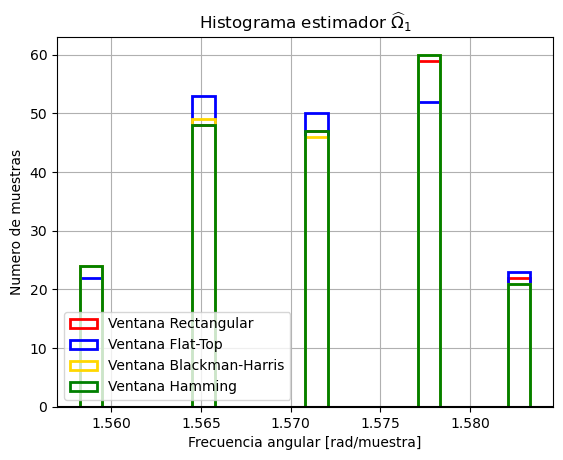

In [31]:
plt.figure(12)
plt.hist(omega_rect, bins=20, color="red", histtype="step", linewidth=2,label="Ventana Rectangular")
plt.hist(omega_flat, bins=20, color="blue", histtype="step", linewidth=2,label="Ventana Flat-Top")
plt.hist(omega_bh, bins=20, color="gold", histtype="step", linewidth=2,label="Ventana Blackman-Harris")
plt.hist(omega_hamm, bins=20, color="green", histtype="step", linewidth=2,label="Ventana Hamming")
plt.title("Histograma estimador $\widehat{\Omega}_1$")
plt.ylabel("Numero de muestras")
plt.xlabel("Frecuencia angular [rad/muestra]")
plt.grid()
plt.axhline(0,color="black")
plt.legend()

In [32]:
print("Rectangular:")
print(f"Media est_omega:{np.round(np.mean(omega_rect),3)} y Varianza:{np.var(omega_rect):.1g}")
sesgo_omega_rect = np.mean(omega_rect - omega_uno)
print(f"Sesgo:{sesgo_omega_rect:.1g}")

print("Flat-Top:")
print(f"Media est_omega:{np.round(np.mean(omega_flat),3)} y Varianza:{np.var(omega_flat):.1g}")
sesgo_omega_flat = np.mean(omega_flat - omega_uno)
print(f"Sesgo:{sesgo_omega_flat:.1g}")

print("Blackman-Harris:")
print(f"Media est_omega:{np.round(np.mean(omega_bh),3)} y Varianza:{np.var(omega_bh):.1g}")
sesgo_omega_bh = np.mean(omega_bh - omega_uno)
print(f"Sesgo:{sesgo_omega_bh:.1g}")

print("Hamming:")
print(f"Media est_omega:{np.round(np.mean(omega_hamm),3)} y Varianza:{np.var(omega_hamm):.1g}")
sesgo_omega_hamm = np.mean(omega_hamm - omega_uno)
print(f"Sesgo:{sesgo_omega_hamm:.1g}")

Rectangular:
Media est_omega:1.571 y Varianza:6e-05
Sesgo:0.0001
Flat-Top:
Media est_omega:1.571 y Varianza:6e-05
Sesgo:-6e-05
Blackman-Harris:
Media est_omega:1.571 y Varianza:6e-05
Sesgo:6e-05
Hamming:
Media est_omega:1.571 y Varianza:6e-05
Sesgo:9e-05


| Ventana | $s_{\widehat{\Omega}_1}$ | $v_{\widehat{\Omega}_1}$ |
|---|---:|---:|
| Rectangular | $1.10^{-4}$ | $6.10^{-5}$ |
| Flat-Top | $-6.10^{-5}$ | $6.10^{-5}$ |
| Blackman-Harris | $6.10^{-5}$ | $6.10^{-5}$ |
| Hamming | $9.10^{-5}$ | $6.10^{-5}$ |

Efectivamente, no se aprecia ningún cambio significativo respecto a los valores obtenidos previamente. Esto nos hace considerar que estos estimadores quizás no se vean afectados en gran medida por el ruido de la señal, más aún a cambios de poca magnitud, y su sesgo y varianza no sean causados por esto si no por las propias características de los mismos estimadores.

# Bonus, propuestas de estimadores alternativos
Propondremos el análisis de que sucede si realizamos dos tipos de modificaciones al estimador, una aditiva y una multiplicativa. Para el primer caso realizaremos un corrimiento mediante restarle el sesgo conocido del caso anterior. Es decir:
\begin{equation}
\widehat{a}_{aditivo} = \widehat{a}_{1} - s_a
\end{equation}
Lo que esperamos de este estimador es que mejore el sesgo sin modificar la varianza, ya que solo estamos realizando un corrimiento de los valores.

Veremos el resultado del estimador original para tres señales senoidales de amplitudes diferentes, para después compararlos con el estimador modificado.

In [33]:
s1 = np.sqrt(2)*np.sin(np.outer(omega_uno,nn))
s1_flat = s1 * flat
freq, s1_flat_fft_abs = mi_fft(s1_flat)
s1_flat_fft_abs_norm = 2*s1_flat_fft_abs/N

s2 = 1*np.sin(np.outer(omega_uno,nn))
s2_flat = s2 * flat
freq, s2_flat_fft_abs = mi_fft(s2_flat)
s2_flat_fft_abs_norm = 2*s2_flat_fft_abs/N

s3 = 12*np.sin(np.outer(omega_uno,nn))
s3_flat = s3 * flat
freq, s3_flat_fft_abs = mi_fft(s3_flat)
s3_flat_fft_abs_norm = 2*s3_flat_fft_abs/N

a_1_s1 = s1_flat_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]
a_1_s2 = s2_flat_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]
a_1_s3 = s3_flat_fft_abs_norm[:,freq==(omega_cero/(2*np.pi))*fs]

print(f"Sesgo caso raiz de 2 V: {np.mean(a_1_s1)-np.sqrt(2):.3g}V y varianza: {np.var(a_1_s1):.3g}")
print(f"Sesgo caso 1 V: {np.mean(a_1_s2)-1:.3g}V y varianza: {np.var(a_1_s2):.3g}")
print(f"Sesgo caso 12 V: {np.mean(a_1_s3)-12:.3g}V y varianza: {np.var(a_1_s3):.3g}")

Sesgo caso raiz de 2 V: -1.13V y varianza: 0.00091
Sesgo caso 1 V: -0.802V y varianza: 0.000455
Sesgo caso 12 V: -9.63V y varianza: 0.0656


In [34]:
def a_1_aditivo(x,sesgo):
    a_1_flat = x[:,freq==(omega_cero/(2*np.pi))*fs]
    a_1_flat_corregido = a_1_flat - sesgo
    return a_1_flat_corregido

In [35]:
sesgo = np.mean(a_1_s1) - np.sqrt(2)

a_1_aditivo_s1 = a_1_aditivo(s1_flat_fft_abs_norm,sesgo)
a_1_aditivo_s2 = a_1_aditivo(s2_flat_fft_abs_norm,sesgo)
a_1_aditivo_s3 = a_1_aditivo(s3_flat_fft_abs_norm,sesgo)

print(f"Sesgo caso raiz de 2 V: {np.mean(a_1_aditivo_s1)-np.sqrt(2):.3g}V y varianza: {np.var(a_1_aditivo_s1):.3g}")
print(f"Sesgo caso 1 V: {np.mean(a_1_aditivo_s2)-1:.3g}V y varianza: {np.var(a_1_aditivo_s2):.3g}")
print(f"Sesgo caso 12 V: {np.mean(a_1_aditivo_s3)-12:.3g}V y varianza: {np.var(a_1_aditivo_s3):.3g}")

Sesgo caso raiz de 2 V: 0V y varianza: 0.00091
Sesgo caso 1 V: 0.332V y varianza: 0.000455
Sesgo caso 12 V: -8.5V y varianza: 0.0656


Podemos ver como para todos los casos, el nuevo estimador fue menos sesgado que el original manteniendo su misma varianza. Sin embargo, al alejarnos del valor de calibración de $a=\sqrt{2}$ el sesgo sigue siendo muy grande. Lo cuál nos hace creer que quizás este no sea el mejor método para modificar nuestro instrumento.

Entonces decidimos plantear el otro caso, utilizar una escala multiplicativa. Esto servirá para recuperar el valor de amplitud que se perdió al aplicar la ventana, utilizando una constante dada por el cociente entre la amplitud esperada y la obtenida:
\begin{equation}
k = \frac{\sqrt{2}}{\widehat{a}_1}
\end{equation}
Este estimador debería, en teoría, mejorar el sesgo. Pero como consecuencia de utilizar una escala multiplicativa, se espera que la varianza aumente de manera proporcional a este factor de escala.

In [36]:
k = np.sqrt(2) / np.mean(a_1_s1)

def a_1_multiplicativo(x, k):
    a_1_flat = k * x[:, freq == (omega_cero/(2*np.pi))*fs]
    return a_1_flat

In [37]:
a_1_multiplicativo_s1 = a_1_multiplicativo(s1_flat_fft_abs_norm, k)
a_1_multiplicativo_s2 = a_1_multiplicativo(s2_flat_fft_abs_norm, k)
a_1_multiplicativo_s3 = a_1_multiplicativo(s3_flat_fft_abs_norm, k)

print(f"Sesgo caso raiz de 2 V: {np.mean(a_1_multiplicativo_s1)-np.sqrt(2):.3g}V y varianza: {np.var(a_1_multiplicativo_s1):.3g}")
print(f"Sesgo caso 1 V: {np.mean(a_1_multiplicativo_s2)-1:.3g}V y varianza: {np.var(a_1_multiplicativo_s2):.3g}")
print(f"Sesgo caso 12 V: {np.mean(a_1_multiplicativo_s3)-12:.3g}V y varianza: {np.var(a_1_multiplicativo_s3):.3g}")

Sesgo caso raiz de 2 V: 0V y varianza: 0.0233
Sesgo caso 1 V: -1.11e-16V y varianza: 0.0117
Sesgo caso 12 V: 0V y varianza: 1.68


Utilizando esta modificación podemos observar como el estimador se convirtió en insesgado, concordando con exactitud con todos los valores de amplitud. Sin embargo, tuvimos que sacrificar el aumento de la varianza para lograrlo. Si se lograra comprobar que este estimador tiene varianza cero con N tendiendo a infinito y, por lo tanto, fuera consistente, estaríamos frente a un muy buen estimador.

# Conclusiones
En este trabajo pudimos ver como la elección, o no, de una ventana para nuestro vector de datos puede modificar su espectro de frecuencia además de todas las mediciones posteriores que haremos sobre el mismo. Aunque no vimos en profundidad sus propiedades ni todos sus usos.

Visualizamos como para los estimadores propuestos el SNR no realizaba prácticamente ningún cambio, aunque si lo haría el ventaneo según el caso.

En el estimador de amplitud vimos como la elección de ventana puede cambiar tanto el sesgo como la varianza del mismo, obteniendo como ventanas a destacar la rectangular como la de menor sesgo y mayor varianza, y la Flat-Top como la de menor varianza y mayor sesgo. 

Además, en el inciso bonus vimos métodos para tratar de mejorar el $\widehat{a}_1$ con la Flat-Top como ventana, viendo que esta es una tarea mas difícil de lo que parece a simple vista. Si realizamos una modificación aditiva, el sesgo mejorará sin incumbir en la varianza, pero el sesgo seguirá siendo fuerte en valores lejos de la referencia. Si en cambio hacemos una modificación multiplicativa, el sesgo mejorará notoriamente para todo el rango de valores, a cambio de sacrificar la varianza.

Por ultimo en el estimador de frecuencia angular vimos como el mismo era bastante robusto, y entregaba valores muy poco sesgados sin importar la ventana que utilizáramos, convirtiéndolo en una herramienta muy buena para medir la frecuencia real de la señal.